# História completa — perfis epidemiológicos de dengue na Bahia

**Trabalho:** Inteligência Artificial IV · aprendizado **não supervisionado**

**Pergunta central:** quais perfis epidemiológicos emergem ao combinar incidência, tendência temporal e contexto municipal, e como municípios transitam entre esses perfis ao longo das semanas?

**Unidade de análise:** município × semana epidemiológica (não semanas de uma cidade só).

**Roteiro deste notebook:**
1. Dados e pipeline
2. Baseline v0 (limitação)
3. Escada de features v0→v5
4. Escolha de K no modelo final
5. Interpretação dos clusters
6. Transições semanais
7. Estabilidade em 10 anos
8. Conclusão

In [2]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

_cwd = Path.cwd().resolve()
if (_cwd / "ml").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "ml").is_dir():
    ROOT = _cwd.parent
else:
    raise RuntimeError("Abra o notebook a partir de ia-iv/ ou ia-iv/notebooks/.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name == "ml" or name.startswith("ml."):
        del sys.modules[name]

from ml.cluster import run_kmeans
from ml.columns import Col, Feat, FEATURE_SETS
from ml.config import DEFAULT_K, DEFAULT_MIN_CASOS_ANUAL, DEFAULT_YEARS, REFERENCE_POP_YEAR
from ml.dataset import build_features_panel, load_region_raw
from ml.experiments import load_experiments
from ml.paths import region_manifest_path
from ml.preprocess import build_region_parquet
from ml.regions import BA
from ml.validate import transition_matrix

VERSION_BLOCKS = {
    "v0": "baseline: casos",
    "v1": "+ incidência por 100 mil",
    "v2": "+ média móvel (3 semanas)",
    "v3": "+ crescimento semanal",
    "v4": "+ aceleração",
    "v5": "+ densidade populacional (hab/km²)",
}

REGION = BA.slug
ANO_FOCO = 2024
K_RANGE = list(range(2, 9))
K_FINAL = DEFAULT_K  # calibrado no Nordeste; validado abaixo no v5
VERSIONS = ["v0", "v1", "v2", "v3", "v4", "v5"]
VERSION_FINAL = "v5"
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
ACCENT = "#0072B2"
SCATTER_KW = dict(s=10, alpha=0.4, linewidths=0.25, edgecolors="#333333")

print(f"Projeto: {ROOT}")
print(f"Python: {sys.executable}")
print(f"Região: {BA.name} | Foco: {ANO_FOCO} | K final: {K_FINAL}")

Projeto: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv
Python: /Users/antonielmagalhaes/d/acad/ia-final/ia-iv/.venv/bin/python
Região: Bahia | Foco: 2024 | K final: 4


---

## 1. Problema e o que **não** estamos fazendo

Dengue varia no **território** e no **tempo**. Totais anuais escondem picos semanais e deslocamentos entre municípios.

| Fazemos | Não fazemos |
|---------|-------------|
| Descobrir perfis recorrentes (clusters) | Prever número exato de casos |
| Acompanhar transições município/semana | Definir oficialmente o que é surto |
| Ferramenta exploratória para vigilância | Substituir critérios epidemiológicos oficiais |

Diferente de classificação supervisionada, **não há rótulos** de risco no SINAN. O K-means agrupa situações semelhantes; depois interpretamos os grupos como estágios de propagação.

---

## 2. Dados

**Fonte:** SINAN / OpenDataSUS (dengue). **Recorte:** Bahia, 2016 a 2025 no parquet agregado; **foco analítico:** 2024.

Em disco ficam só dois artefatos: `dengue.parquet` (notificações + coluna `year`) e `populacao.parquet` (referência IBGE única). Features são calculadas **em memória**.

,notificações
2016,83378
2017,15463
2018,14151
2019,84715
2020,107369
2021,36833
2022,35724
2023,47419
2024,231942
2025,32455



2024: 231942 notificações | 352 municípios elegíveis (≥30 casos/ano) | 18,304 linhas município×semana
População/densidade: referência IBGE 2024


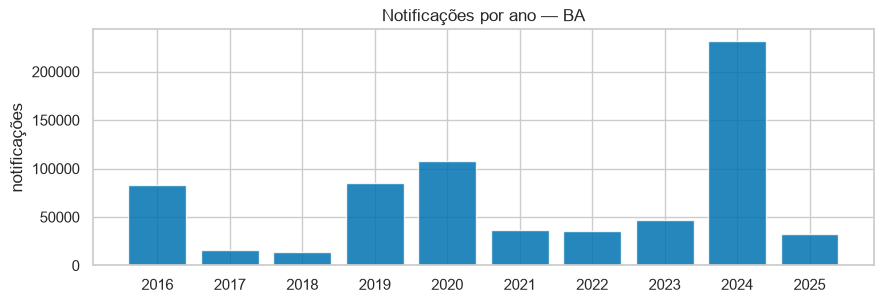

In [3]:
build_region_parquet(BA, DEFAULT_YEARS)
manifest = json.loads(region_manifest_path(REGION).read_text(encoding="utf-8"))
pop = pd.read_parquet(ROOT / "data/ml/ba/populacao.parquet")

by_year = pd.Series(manifest["registros_por_ano"], name="notificações").astype(int)
by_year.index = by_year.index.astype(int)
display(by_year.to_frame())

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(by_year.index.astype(str), by_year.values, color=ACCENT, alpha=0.85)
ax.set_title("Notificações por ano — BA")
ax.set_ylabel("notificações")
plt.tight_layout()

panel_probe = build_features_panel(REGION, ANO_FOCO, "v0")
print(
    f"\n{ANO_FOCO}: {by_year.get(ANO_FOCO, '?')} notificações | "
    f"{panel_probe[Col.ID_MUNICIP].nunique()} municípios elegíveis (≥{DEFAULT_MIN_CASOS_ANUAL} casos/ano) | "
    f"{len(panel_probe):,} linhas município×semana"
)
print(f"População/densidade: referência IBGE {REFERENCE_POP_YEAR}")

---

## 3. Baseline v0 — casos absolutos

Primeiro passo: clusterizar só **casos da semana**. Funciona tecnicamente, mas favorece municípios populosos. Silhouette alta aqui é armadilha: em 1D o cluster vira quase ordenação por volume.

In [4]:
def run_version(version: str, k: int = K_FINAL):
    panel = build_features_panel(REGION, ANO_FOCO, version)
    result = run_kmeans(panel, version, k=k)
    return {"version": version, "panel": panel, "result": result}

res_v0 = run_version("v0")
sizes_v0 = pd.Series(res_v0["result"].labels).value_counts().sort_index()
pct_base = 100 * sizes_v0.get(0, 0) / len(res_v0["panel"])

print(f"silhouette v0: {res_v0['result'].metrics['silhouette']:.3f}")
print(f"Cluster 0 concentra {pct_base:.1f}% das linhas município×semana")
display(res_v0["result"].cluster_means.round(2))
display(sizes_v0.rename("linhas"))

silhouette v0: 0.923
Cluster 0 concentra 97.1% das linhas município×semana


,casos
cluster,
0,5.22
1,159.36
2,638.51
3,2539.54


0    17773
1      463
2       57
3       11
Name: linhas, dtype: int64

---

## 4. Escada v0→v5 (+1 feature por versão)

Cada versão **adiciona** uma feature (cumulativo). Usamos K=4 provisório para comparar versões entre si.

,versão,bloco,silhouette,davies_bouldin,n_feat,Δ silhouette
0,v0,baseline: casos,0.9230,0.4512,1,NaN
1,v1,+ incidência por 100 mil,0.8780,0.6064,2,-0.0451
2,v2,+ média móvel (3 semanas),0.8691,0.5671,3,-0.0089
3,v3,+ crescimento semanal,0.8495,0.8861,4,-0.0196
4,v4,+ aceleração,0.8497,0.8667,5,0.0002
5,v5,+ densidade populacional (hab/km²),0.8446,0.8848,6,-0.0052


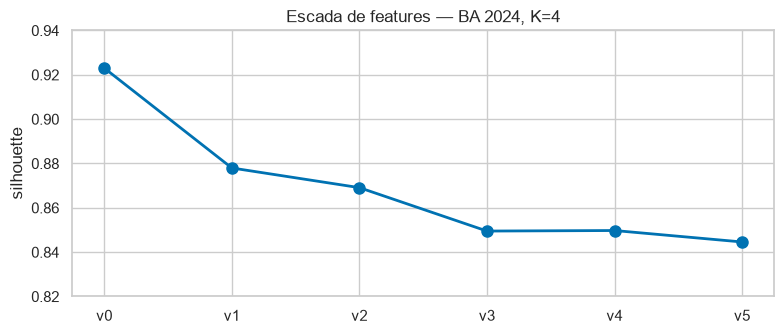

In [5]:
runs_ladder = [run_version(v) for v in VERSIONS]
runs_by = {r["version"]: r for r in runs_ladder}

evo = pd.DataFrame([{
    "versão": r["version"],
    "bloco": VERSION_BLOCKS[r["version"]],
    "silhouette": r["result"].metrics["silhouette"],
    "davies_bouldin": r["result"].metrics["davies_bouldin"],
    "n_feat": len(FEATURE_SETS[r["version"]]),
} for r in runs_ladder])
evo["Δ silhouette"] = evo["silhouette"].diff().round(4)
display(evo.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(evo["versão"], evo["silhouette"], "o-", color=ACCENT, lw=2, markersize=8)
ax.set_ylim(0.82, 0.94)
ax.set_ylabel("silhouette")
ax.set_title(f"Escada de features — BA {ANO_FOCO}, K={K_FINAL}")
plt.tight_layout()

### 4.1 v1 — incidência compara municípios

Na Bahia agregada, **v1 ≠ v0**: dois municípios com casos parecidos podem ter incidências distintas.

In [6]:
panel_v1 = runs_by["v1"]["panel"]
sem_pico = panel_v1.groupby(Col.SEM_NOT)[Feat.CASOS].sum().idxmax()
snap = panel_v1[panel_v1[Col.SEM_NOT] == sem_pico].nlargest(8, Feat.CASOS)
snap = snap.merge(pop[["id_municip", "municipio"]], left_on=Col.ID_MUNICIP, right_on="id_municip")
display(snap[["municipio", Feat.CASOS, Feat.INCIDENCIA_100K]].round(2))

,municipio,casos,incidencia_100k
0,Vitória da Conquista,3029,768.73
1,Caetité,1218,2231.91
2,Barra do Choça,1130,2936.51
3,Feira de Santana,635,96.51
4,Santo Antônio de Jesus,566,518.00
5,Salvador,483,18.80
6,Guanambi,478,513.62
7,Bom Jesus da Lapa,415,604.04


### 4.2 v4 — dinâmica temporal (crescimento e aceleração)

,casos,incidencia_100k,media_movel_3,crescimento,aceleracao
cluster,,,,,
0,6.02,17.85,18.71,-0.48,1.12
1,78.84,340.33,425.74,-185.08,-298.99
2,112.14,466.69,376.84,157.21,201.54
3,1992.11,1216.59,1086.71,104.89,-74.96


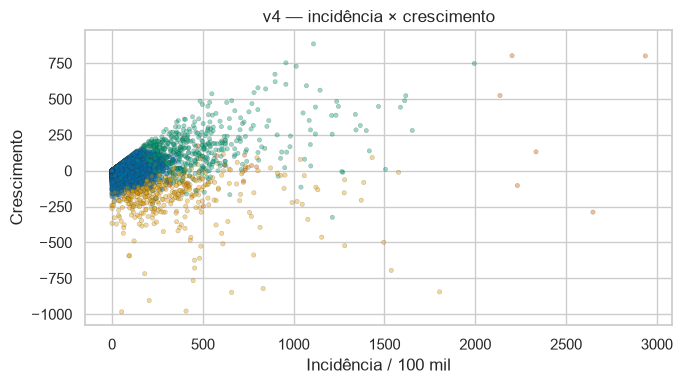

In [7]:
res_v4 = runs_by["v4"]["result"]
labeled_v4 = runs_by["v4"]["panel"].assign(cluster=res_v4.labels)
display(res_v4.cluster_means.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
colors = labeled_v4["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(labeled_v4[Feat.INCIDENCIA_100K], labeled_v4[Feat.CRESCIMENTO], c=colors, **SCATTER_KW)
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Crescimento")
ax.set_title("v4 — incidência × crescimento")
plt.tight_layout()

### 4.3 v5 — densidade (contexto urbano vs interior)

Silhouette cai pouco vs v4; o ganho é **interpretação**, não métrica interna.

In [8]:
res_v5_ladder = runs_by["v5"]["result"]
print(
    f"silhouette v4→v5: "
    f"{runs_by['v4']['result'].metrics['silhouette']:.4f} → {res_v5_ladder.metrics['silhouette']:.4f}"
)
display(res_v5_ladder.cluster_means.round(2))

silhouette v4→v5: 0.8497 → 0.8446


,casos,incidencia_100k,media_movel_3,crescimento,aceleracao,densidade_km2
cluster,,,,,,
0,5.57,19.15,19.74,0.03,1.86,42.65
1,81.96,341.14,427.50,-187.29,-302.79,29.90
2,110.28,5.38,5.36,0.01,0.00,3733.15
3,199.77,540.15,440.60,167.51,203.27,37.61


---

## 5. Escolha de K (modelo final v5)

Com a escada fechada, calibramos **K** no conjunto de features v5. Métricas internas sozinhas empurram K alto; buscamos equilíbrio com interpretabilidade (referência: cotovelo no Nordeste → K=4).

,K,silhouette,davies_bouldin,inertia,menor_cluster
0,2,0.8470,1.0531,84299.5992,569
1,3,0.8582,0.8666,66913.6846,104
2,4,0.8446,0.8848,53053.8340,104
3,5,0.8390,0.8014,42093.3257,18
4,6,0.8143,0.8053,36500.4532,12
5,7,0.7876,0.8690,32079.0462,11
6,8,0.7524,0.8863,29089.0539,11


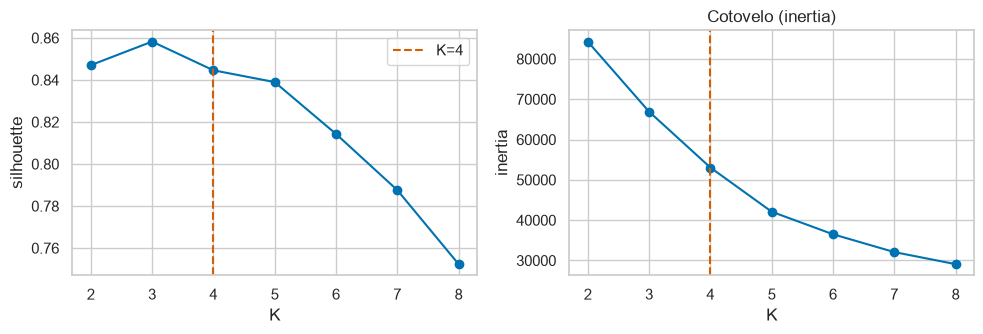

In [9]:
panel_v5 = build_features_panel(REGION, ANO_FOCO, VERSION_FINAL)

k_rows = []
for k in K_RANGE:
    r = run_kmeans(panel_v5, VERSION_FINAL, k=k)
    sizes = pd.Series(r.labels).value_counts()
    k_rows.append({
        "K": k,
        "silhouette": r.metrics["silhouette"],
        "davies_bouldin": r.metrics["davies_bouldin"],
        "inertia": r.metrics["inertia"],
        "menor_cluster": int(sizes.min()),
    })

k_df = pd.DataFrame(k_rows)
display(k_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(k_df["K"], k_df["silhouette"], "o-", color=ACCENT)
axes[0].axvline(K_FINAL, color="#D55E00", ls="--", label=f"K={K_FINAL}")
axes[0].set_xlabel("K")
axes[0].set_ylabel("silhouette")
axes[0].legend()

axes[1].plot(k_df["K"], k_df["inertia"], "o-", color=ACCENT)
axes[1].axvline(K_FINAL, color="#D55E00", ls="--")
axes[1].set_xlabel("K")
axes[1].set_ylabel("inertia")
axes[1].set_title("Cotovelo (inertia)")
plt.tight_layout()

---

## 6. Perfis dos clusters (v5, K=4)

Nomes abaixo são **interpretação pós-cluster**, não rótulos oficiais de vigilância.

,casos,incidencia_100k,media_movel_3,crescimento,aceleracao,densidade_km2,leitura
cluster,,,,,,,
0,5.57,19.15,19.74,0.03,1.86,42.65,baixa incidência (interior)
1,81.96,341.14,427.50,-187.29,-302.79,29.90,incidência moderada em queda
2,110.28,5.38,5.36,0.01,0.00,3733.15,"urbano denso, baixa incidência"
3,199.77,540.15,440.60,167.51,203.27,37.61,alta incidência em crescimento


cluster
0    17344
1      408
2      104
3      448
Name: linhas, dtype: int64

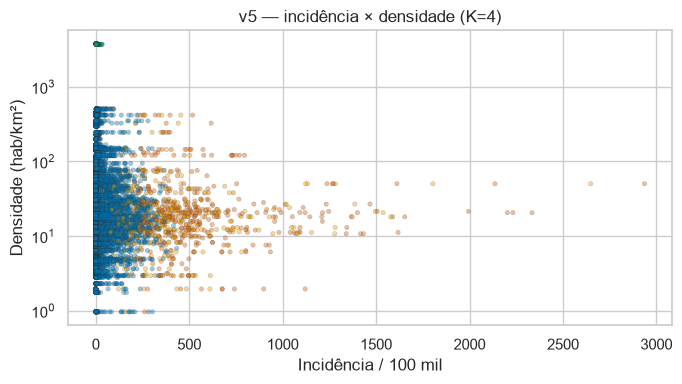

In [10]:
res_final = run_kmeans(panel_v5, VERSION_FINAL, k=K_FINAL)
labeled = panel_v5.assign(cluster=res_final.labels)
means = res_final.cluster_means.round(2)

NOMES = {}
for c in means.index:
    row = means.loc[c]
    if row[Feat.DENSIDADE_KM2] > 500:
        nome = "urbano denso, baixa incidência"
    elif row[Feat.CRESCIMENTO] > 50:
        nome = "alta incidência em crescimento"
    elif row[Feat.CRESCIMENTO] < -50:
        nome = "incidência moderada em queda"
    else:
        nome = "baixa incidência (interior)"
    NOMES[int(c)] = nome

perfis = means.copy()
perfis["leitura"] = perfis.index.map(NOMES)
display(perfis)

sizes = labeled["cluster"].value_counts().sort_index()
display(sizes.rename("linhas"))

fig, ax = plt.subplots(figsize=(7, 4))
colors = labeled["cluster"].map({i: PALETTE[i] for i in range(K_FINAL)})
ax.scatter(labeled[Feat.INCIDENCIA_100K], labeled[Feat.DENSIDADE_KM2], c=colors, **SCATTER_KW)
ax.set_xlabel("Incidência / 100 mil")
ax.set_ylabel("Densidade (hab/km²)")
ax.set_yscale("log")
ax.set_title(f"v5 — incidência × densidade (K={K_FINAL})")
plt.tight_layout()

---

## 7. Transições semana t→t+1

Como cada município muda de perfil entre semanas consecutivas. Análise **posterior** ao clustering (não treina o modelo).

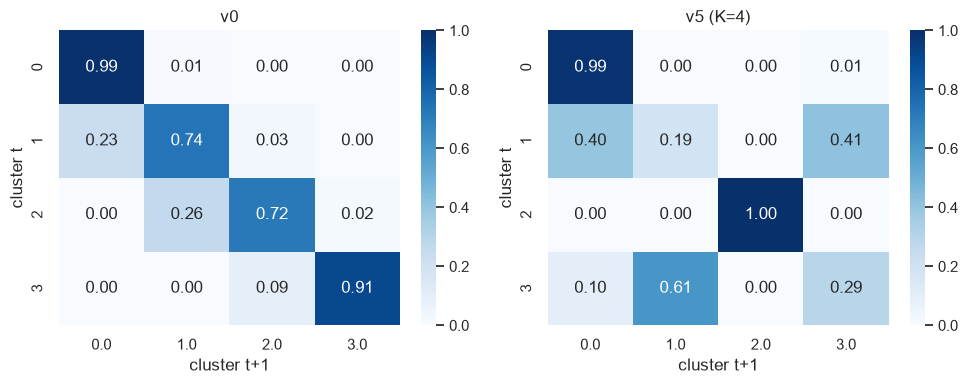

In [11]:
trans_v0 = transition_matrix(runs_by["v0"]["panel"], runs_by["v0"]["result"].labels)
trans_v5 = transition_matrix(panel_v5, res_final.labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, trans, title in [(axes[0], trans_v0, "v0"), (axes[1], trans_v5, f"v5 (K={K_FINAL})")]:
    sns.heatmap(trans, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
    ax.set_xlabel("cluster t+1")
    ax.set_ylabel("cluster t")
    ax.set_title(title)
plt.tight_layout()

---

## 8. Estabilidade em 10 anos (v0 vs v5)

A escada se comporta de forma parecida ao longo do tempo? Comparamos silhouette de v0 e v5 em cada ano (K=4).

,ano,v0,v5,Δ (v5−v0)
0,2016,0.9347,0.9026,-0.0322
1,2017,0.7942,0.8910,0.0968
2,2018,0.8240,0.8497,0.0257
3,2019,0.8612,0.8003,-0.0609
4,2020,0.8598,0.8283,-0.0315
5,2021,0.8665,0.8523,-0.0142
6,2022,0.8354,0.8458,0.0104
7,2023,0.9054,0.8376,-0.0678
8,2024,0.9230,0.8446,-0.0784
9,2025,0.8425,0.8452,0.0027


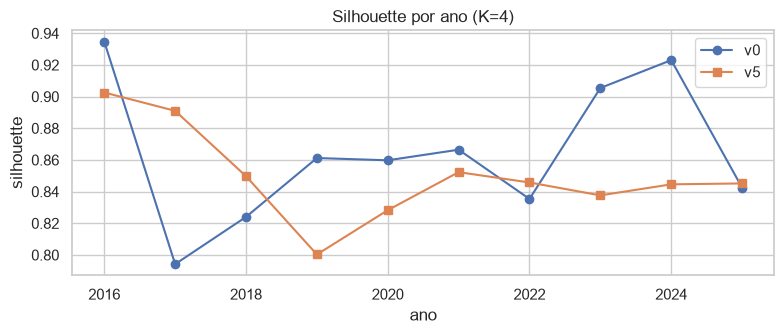

In [12]:
def silhouette_ano(year: int, version: str) -> float:
    panel = build_features_panel(REGION, year, version)
    return float(run_kmeans(panel, version, k=K_FINAL).metrics["silhouette"])

estab = pd.DataFrame({
    "ano": DEFAULT_YEARS,
    "v0": [silhouette_ano(y, "v0") for y in DEFAULT_YEARS],
    "v5": [silhouette_ano(y, VERSION_FINAL) for y in DEFAULT_YEARS],
})
estab["Δ (v5−v0)"] = estab["v5"] - estab["v0"]
display(estab.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(estab["ano"], estab["v0"], "o-", label="v0")
ax.plot(estab["ano"], estab["v5"], "s-", label="v5")
ax.set_xlabel("ano")
ax.set_ylabel("silhouette")
ax.set_title(f"Silhouette por ano (K={K_FINAL})")
ax.legend()
plt.tight_layout()

---

## 9. Log de experimentos e limitações

**Limitações:** população fixa (IBGE 2024); clustering semanal independente; subnotificação; sem clima defasado ainda; validação causal não feita.

**Conclusão:** a história não é prever surto, é transformar séries semanais em **estágios interpretáveis** e observar **transições**. v0 mostra o limite de casos brutos; v1 a v4 trazem dinâmica; v5 contextualiza urbano vs interior; K=4 equilibra métrica e leitura.

In [13]:
exp_df = pd.json_normalize(load_experiments())
if "config.region" in exp_df.columns:
    mask = (exp_df["config.region"] == REGION) & (exp_df["config.year"] == ANO_FOCO)
    cols = [c for c in ["id", "tag", "config.feature_version", "metrics.silhouette", "config.k"] if c in exp_df.columns]
    display(exp_df[mask].sort_values("id")[cols].tail(8).round(4))
else:
    print("Log experiments.jsonl disponível via: uv run ia-iv-exp list")

,id,tag,config.feature_version,metrics.silhouette,config.k
12,exp_013,v0-ba,v0,0.9230,4
13,exp_014,v1-ba,v1,0.8780,4
14,exp_015,v2-ba,v2,0.8691,4
15,exp_016,v3-ba,v3,0.8495,4
16,exp_017,v4-ba,v4,0.8497,4
17,exp_018,v5-densidade,v5,0.8446,4
